In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


2026-01-31 13:53:47.229797: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769867627.428624      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769867627.486428      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769867627.943072      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769867627.943117      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769867627.943122      17 computation_placer.cc:177] computation placer alr

In [3]:
np.random.seed(42)

#  parameters
m_true = 3 #weight
b_true = 10 #bias


x = np.random.rand(1000, 1) * 10  #random1000 numbers from1to 10

# Add Gaussian noise
noise = np.random.normal(0, 2, size=(1000, 1))

# Linear relationship
y = m_true * x + b_true + noise


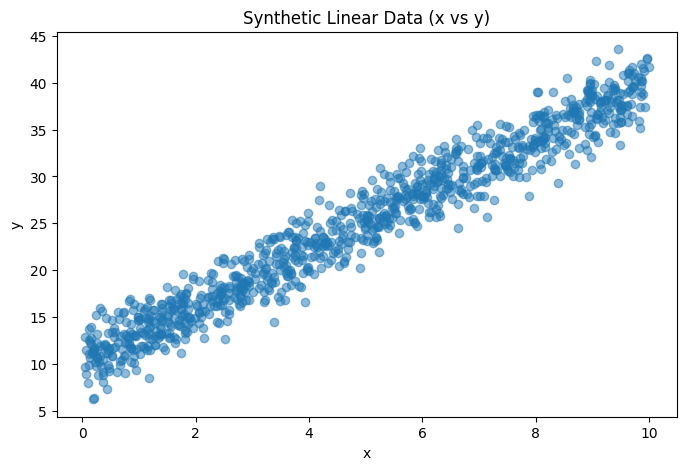

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic Linear Data (x vs y)")
plt.show()


In [5]:
#split data 

x_train, x_test, y_train, y_test = train_test_split(
    x,          
    y,          
    test_size=0.2, 
    random_state=42 
)

In [6]:
model = Sequential([
    Dense(1, input_shape=(1,))
])
print("Model Architecture:")
print(model.summary())

model.compile(
    optimizer='sgd', 
    
    loss='mse'
)


Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-31 13:54:04.402983: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    verbose=1
)

#loss evaluation
y_test_pred = model.predict(x_test)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Test MSE: {mse_test:.3f}")

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 73.2542   
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 21.9863 
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.9853 
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.6783 
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12.7199
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.1979 
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.4529 
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.8651 
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.1606 
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0877 
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2368 
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.5892 
Epoch 13/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.0923 
Epoch 14/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.9125 
Epoch 15/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.034

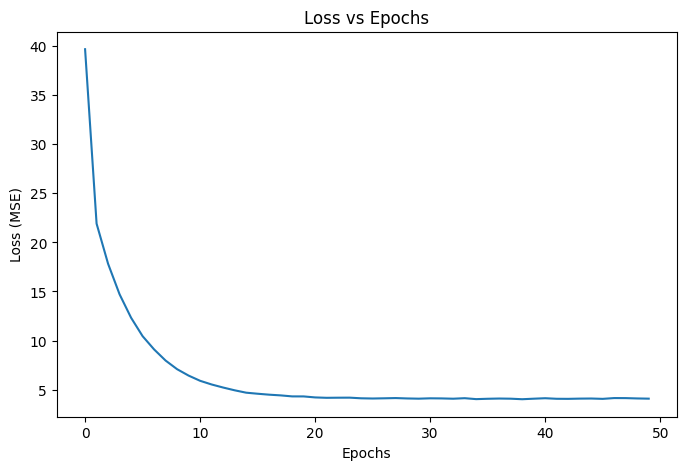

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epochs")
plt.show()


In [9]:
weights, bias = model.layers[0].get_weights()

learned_m = weights[0][0]
learned_b = bias[0]


print(f"True Weight (m): {m_true}")
print(f"Learned Weight (m): {learned_m:.4f}")

print(f"\nTrue Bias (b): {b_true}")
print(f"Learned Bias (b): {learned_b:.4f}")


True Weight (m): 3
Learned Weight (m): 2.8983

True Bias (b): 10
Learned Bias (b): 10.3410


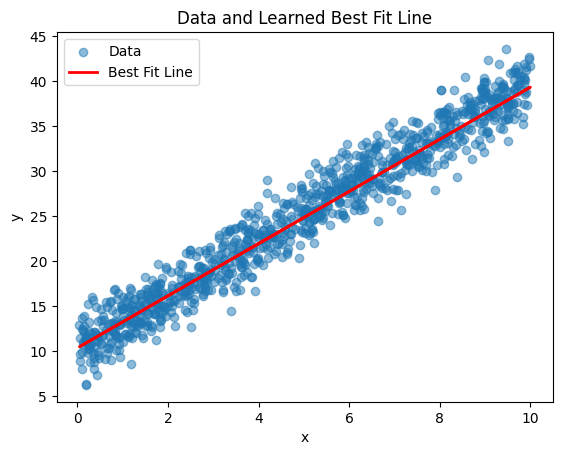

In [10]:
# Overlay best fit line on scatter plot
plt.scatter(x, y, alpha=0.5, label="Data")
y_pred = learned_m * x + learned_b 
plt.plot(x, y_pred, color='red', linewidth=2, label="Best Fit Line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data and Learned Best Fit Line")
plt.legend()
plt.show()